In [1]:
import pandas as pd

df = pd.read_csv("../data/Steel_industry_data.csv")
print(df.head())
print(df.columns.tolist())

               date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0  01/01/2018 00:15       3.17                                  2.95   
1  01/01/2018 00:30       4.00                                  4.46   
2  01/01/2018 00:45       3.24                                  3.28   
3  01/01/2018 01:00       3.31                                  3.56   
4  01/01/2018 01:15       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77                         100.0  1800   
2                         70.

In [3]:
# ===========================================
# Import Required Libraries
# ===========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [4]:
# ===========================================
# Load Dataset
# ===========================================

df = pd.read_csv("../data/Steel_industry_data.csv")

# Display first five rows
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


In [5]:
# ===========================================
# Dataset Overview
# ===========================================

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape of Dataset:
(35040, 11)

Column Names:
['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh', 'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)', 'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM', 'WeekStatus', 'Day_of_week', 'Load_Type']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  f

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000



Missing Values:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64

Duplicate Rows:
0


In [6]:
# ===========================================
# Convert Date Column
# ===========================================

df['date'] = pd.to_datetime(df['date'], dayfirst=True)

print(df['date'].head())

0   2018-01-01 00:15:00
1   2018-01-01 00:30:00
2   2018-01-01 00:45:00
3   2018-01-01 01:00:00
4   2018-01-01 01:15:00
Name: date, dtype: datetime64[ns]


In [7]:
# ===========================================
# Feature Engineering
# ===========================================

# Hour of Day
df['Hour'] = df['date'].dt.hour

# Day of Week
df['Day_of_Week_New'] = df['date'].dt.day_name()

# Month
df['Month'] = df['date'].dt.month_name()

# Weekday / Weekend
df['Day_Type'] = np.where(df['date'].dt.weekday < 5,
                          "Weekday",
                          "Weekend")

# Power Factor Ratio
df['Power_Factor_Ratio'] = (
    df['Leading_Current_Power_Factor']
    /
    df['Lagging_Current_Power_Factor']
)

# High Load Feature
threshold = df['Usage_kWh'].quantile(0.75)

df['High_Load'] = np.where(df['Usage_kWh'] > threshold,
                           1,
                           0)

df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_of_Week_New,Month,Day_Type,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.545117,0


In [8]:
# ===========================================
# Outlier Detection using IQR
# ===========================================

Q1 = df['Usage_kWh'].quantile(0.25)

Q3 = df['Usage_kWh'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Usage_kWh'] < lower) |
    (df['Usage_kWh'] > upper)
]

print("Number of Outliers:", len(outliers))

Number of Outliers: 328


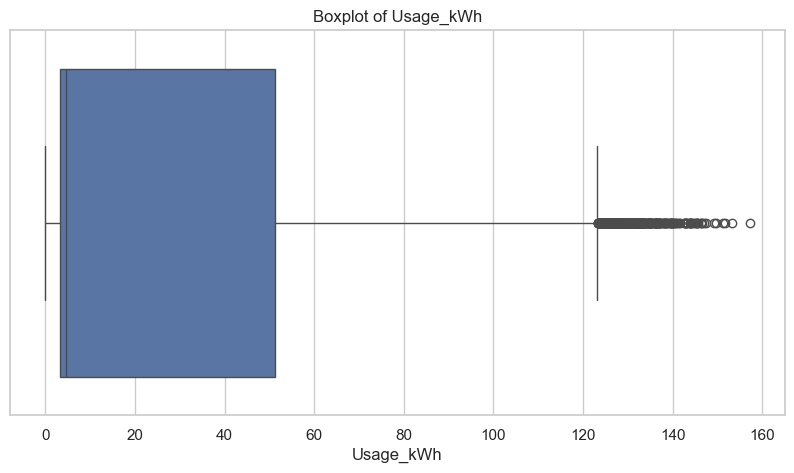

In [9]:
# ===========================================
# Boxplot
# ===========================================

plt.figure(figsize=(10,5))

sns.boxplot(x=df['Usage_kWh'])

plt.title("Boxplot of Usage_kWh")

plt.xlabel("Usage_kWh")

plt.show()

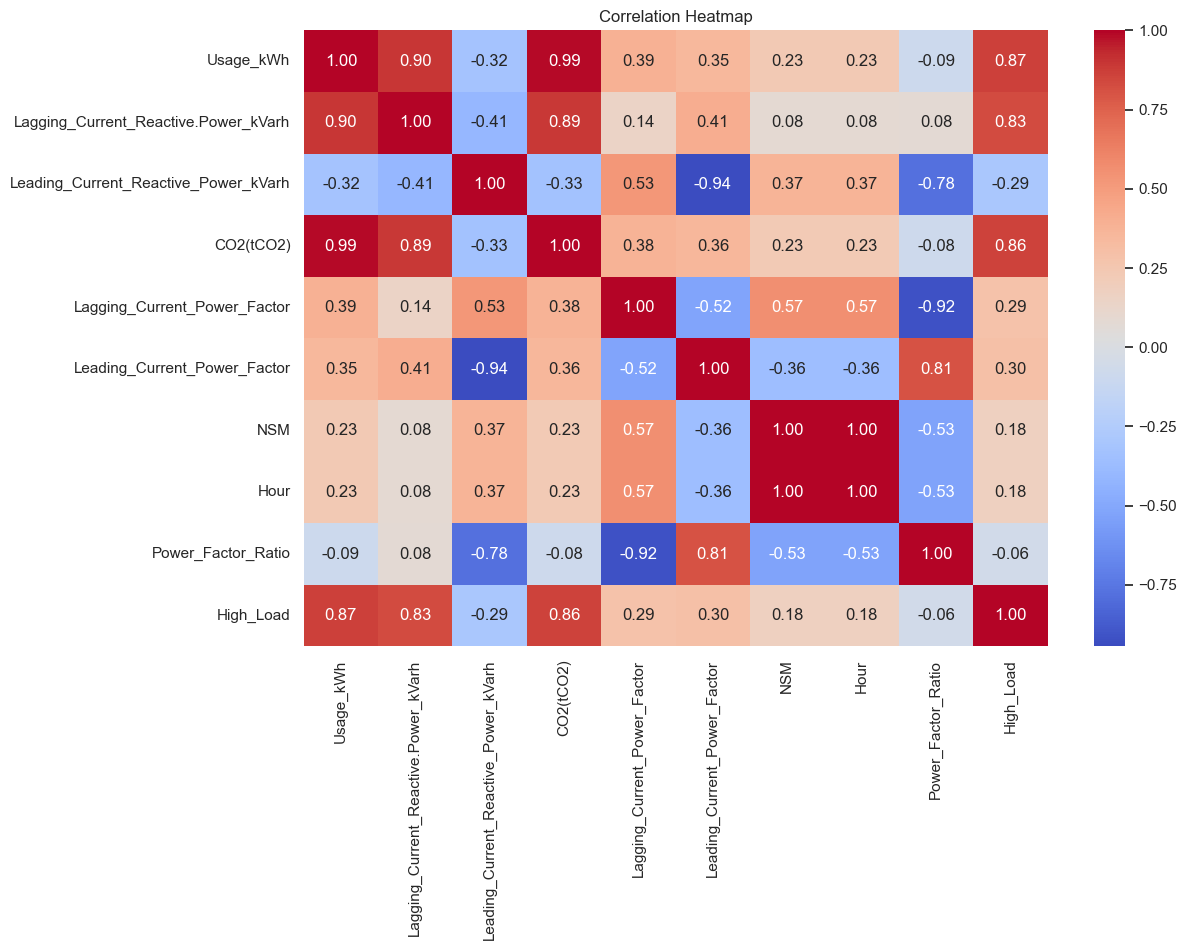

In [10]:
# ===========================================
# Correlation Heatmap
# ===========================================

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

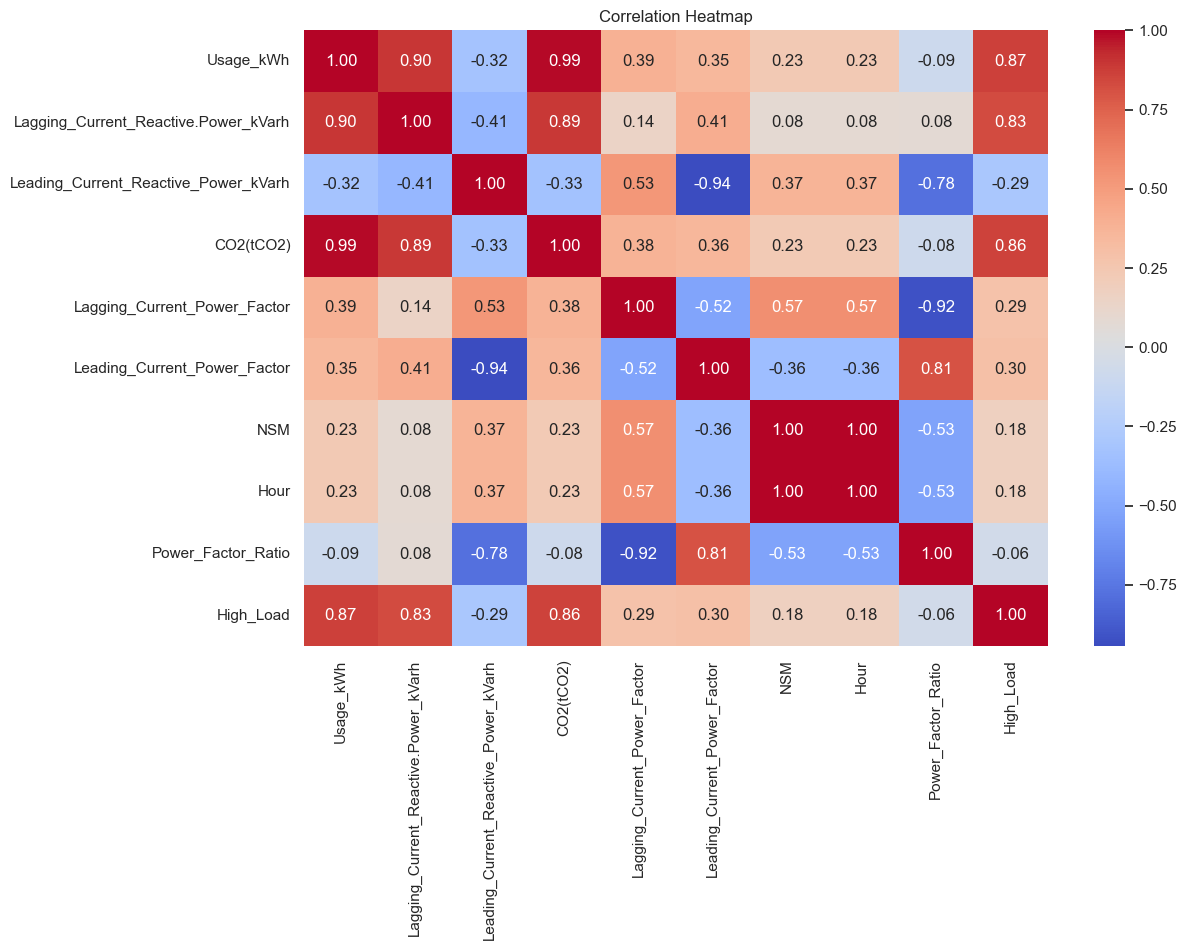

In [11]:
# ===========================================
# Correlation Heatmap
# ===========================================

plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

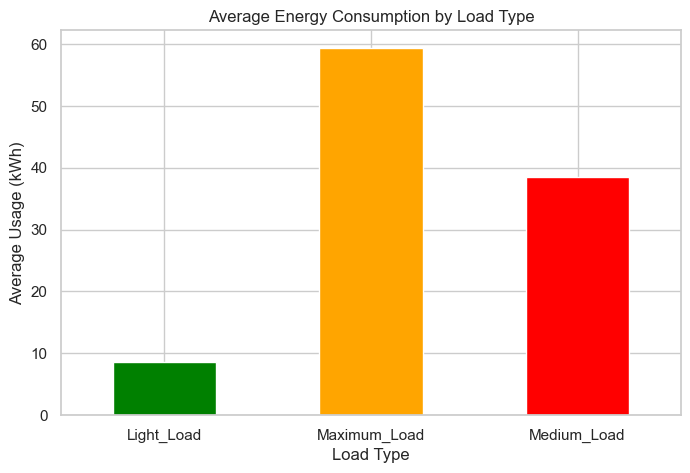

In [12]:
# ===========================================
# Average Usage by Load Type
# ===========================================

avg_load = df.groupby(
    'Load_Type'
)['Usage_kWh'].mean()

plt.figure(figsize=(8,5))

avg_load.plot(
    kind='bar',
    color=['green','orange','red']
)

plt.title("Average Energy Consumption by Load Type")

plt.ylabel("Average Usage (kWh)")

plt.xlabel("Load Type")

plt.xticks(rotation=0)

plt.show()

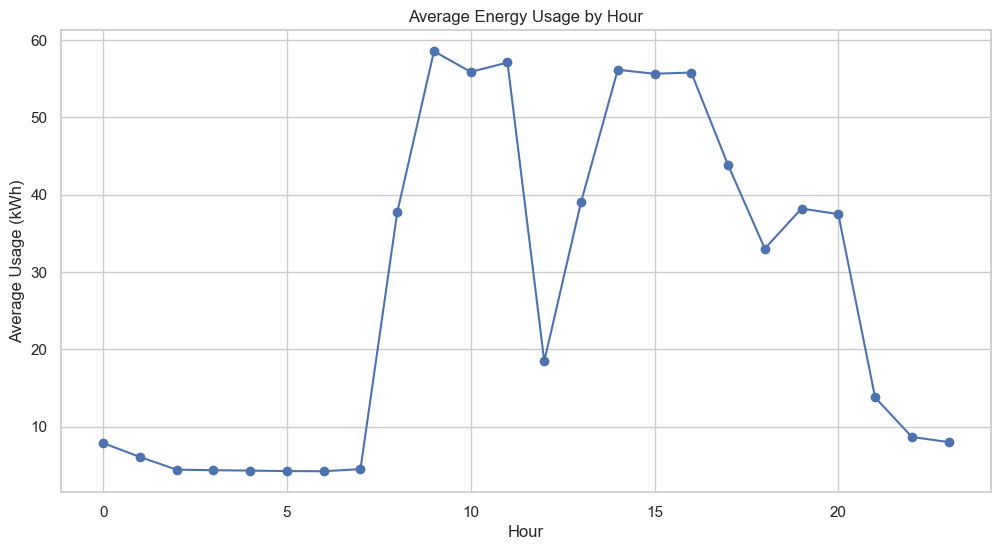

In [13]:
# ===========================================
# Average Usage by Hour
# ===========================================

hour_avg = df.groupby(
    'Hour'
)['Usage_kWh'].mean()

plt.figure(figsize=(12,6))

plt.plot(
    hour_avg.index,
    hour_avg.values,
    marker='o'
)

plt.title("Average Energy Usage by Hour")

plt.xlabel("Hour")

plt.ylabel("Average Usage (kWh)")

plt.grid(True)

plt.show()

In [17]:
# ===========================================
# Save Engineered Dataset
# ===========================================

df.to_csv(
    "../data/Steel_Energy_Engineered.csv",
    index=False
)

print("Engineered dataset saved successfully!")

Engineered dataset saved successfully!


In [18]:
# ===========================================
# Check Missing Values
# ===========================================

print("Missing Values in Each Column:\n")

missing_values = df.isnull().sum()

print(missing_values)

Missing Values in Each Column:

date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
Hour                                    0
Day_of_Week_New                         0
Month                                   0
Day_Type                                0
Power_Factor_Ratio                      1
High_Load                               0
dtype: int64


In [19]:
# Total Missing Values

total_missing = df.isnull().sum().sum()

print(f"\nTotal Missing Values: {total_missing}")


Total Missing Values: 1


In [20]:
# ===========================================
# Missing Value Percentage
# ===========================================

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": missing_percentage
})

print(missing_df)

                                      Missing Values  Percentage (%)
date                                               0        0.000000
Usage_kWh                                          0        0.000000
Lagging_Current_Reactive.Power_kVarh               0        0.000000
Leading_Current_Reactive_Power_kVarh               0        0.000000
CO2(tCO2)                                          0        0.000000
Lagging_Current_Power_Factor                       0        0.000000
Leading_Current_Power_Factor                       0        0.000000
NSM                                                0        0.000000
WeekStatus                                         0        0.000000
Day_of_week                                        0        0.000000
Load_Type                                          0        0.000000
Hour                                               0        0.000000
Day_of_Week_New                                    0        0.000000
Month                             

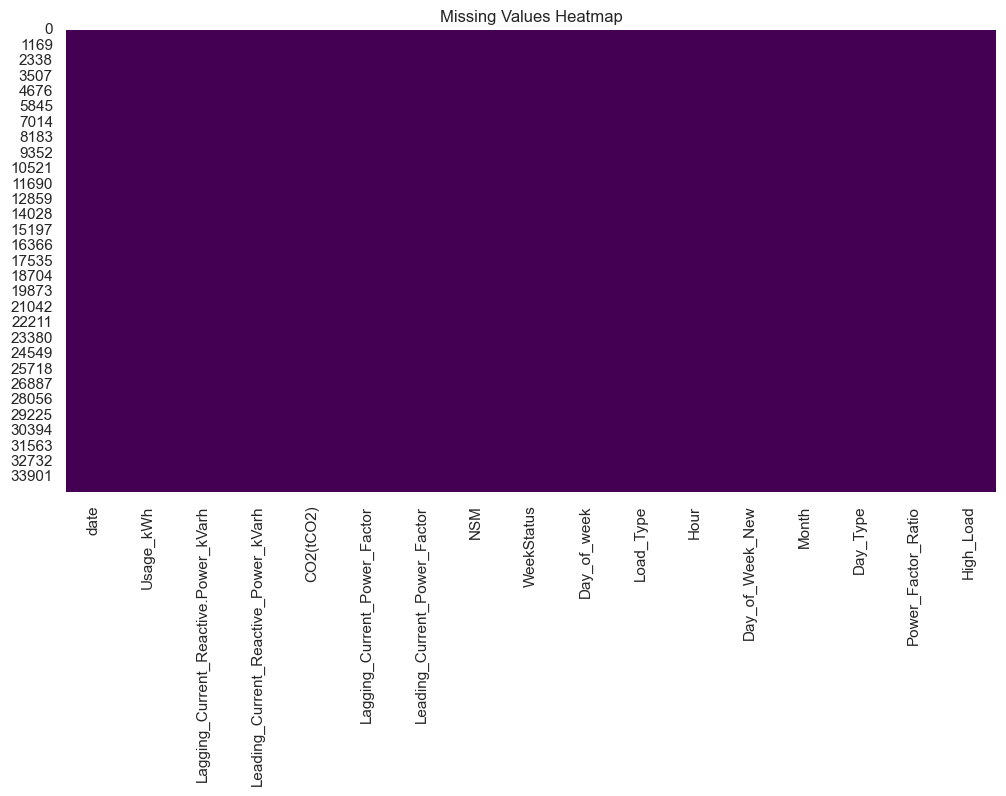

In [21]:
# ===========================================
# Missing Value Heatmap
# ===========================================

plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.show()

In [22]:
# Fill missing value with the median
df['Power_Factor_Ratio'].fillna(
    df['Power_Factor_Ratio'].median(),
    inplace=True
)

In [23]:
print(df['Power_Factor_Ratio'].isnull().sum())

0


In [25]:
df.to_csv("../data/Steel_Energy_Engineered.csv", index=False)

In [2]:
# ===========================================
# Import Required Libraries
# ===========================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings

warnings.filterwarnings("ignore")

In [3]:
# ===========================================
# Load Engineered Dataset
# ===========================================

df = pd.read_csv("../data/Steel_Energy_Engineered.csv")

df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_of_Week_New,Month,Day_Type,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.545117,0


In [4]:
# ===========================================
# Drop Unnecessary Columns
# ===========================================

df = df.drop(
    columns=[
        "date",
        "High_Load"
    ]
)

df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_of_Week_New,Month,Day_Type,Power_Factor_Ratio
0,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.365934
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.497679
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.422880
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.468644
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.545117


In [5]:
# ===========================================
# One-Hot Encoding
# ===========================================

df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,Hour,Power_Factor_Ratio,WeekStatus_Weekend,...,Month_February,Month_January,Month_July,Month_June,Month_March,Month_May,Month_November,Month_October,Month_September,Day_Type_Weekend
0,3.17,2.95,0.0,0.0,73.21,100.0,900,0,1.365934,False,...,False,True,False,False,False,False,False,False,False,False
1,4.00,4.46,0.0,0.0,66.77,100.0,1800,0,1.497679,False,...,False,True,False,False,False,False,False,False,False,False
2,3.24,3.28,0.0,0.0,70.28,100.0,2700,0,1.422880,False,...,False,True,False,False,False,False,False,False,False,False
3,3.31,3.56,0.0,0.0,68.09,100.0,3600,1,1.468644,False,...,False,True,False,False,False,False,False,False,False,False
4,3.82,4.50,0.0,0.0,64.72,100.0,4500,1,1.545117,False,...,False,True,False,False,False,False,False,False,False,False


In [6]:
# ===========================================
# Features and Target
# ===========================================

X = df.drop(
    "Usage_kWh",
    axis=1
)

y = df["Usage_kWh"]

print(X.shape)

print(y.shape)

(35040, 35)
(35040,)


In [7]:
# ===========================================
# Train Test Split
# ===========================================

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

print("Training Samples:", X_train.shape)

print("Testing Samples:", X_test.shape)

Training Samples: (28032, 35)
Testing Samples: (7008, 35)


Training Samples: (28032, 35)
Testing Samples: (7008, 35)


In [16]:

# ===========================================
# Create Models
# ===========================================

models = {

    "Linear Regression":
    LinearRegression(),

    "Ridge Regression":
    Ridge(alpha=1.0),

    "Decision Tree":
    DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest":
    RandomForestRegressor(

        n_estimators=50,

        random_state=42,

        n_jobs=1,

    )

}


In [10]:
# ===========================================
# Train Models
# ===========================================

for name, model in models.items():

    model.fit(

        X_train,

        y_train

    )

print("All Models Trained Successfully!")

All Models Trained Successfully!


In [11]:
# ===========================================
# Model Evaluation
# ===========================================

results = []

for name, model in models.items():

    predictions = model.predict(X_test)

    mae = mean_absolute_error(

        y_test,

        predictions

    )

    rmse = np.sqrt(

        mean_squared_error(

            y_test,

            predictions

        )

    )

    r2 = r2_score(

        y_test,

        predictions

    )

    results.append([

        name,

        mae,

        rmse,

        r2

    ])

results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "MAE",

        "RMSE",

        "R2 Score"

    ]

)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,2.668221,4.124352,0.985036
1,Ridge Regression,4.325466,6.201066,0.966172
2,Decision Tree,0.546941,1.618502,0.997696
3,Random Forest,0.346099,1.039767,0.999049


In [12]:
# ===========================================
# Model Comparison
# ===========================================

results_df = results_df.sort_values(

    by="RMSE"

)

results_df

,Model,MAE,RMSE,R2 Score
3,Random Forest,0.346099,1.039767,0.999049
2,Decision Tree,0.546941,1.618502,0.997696
0,Linear Regression,2.668221,4.124352,0.985036
1,Ridge Regression,4.325466,6.201066,0.966172


In [17]:
# ===========================================
# Cross Validation
# ===========================================

from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=1,
        verbose=1
    )

    rmse = -scores.mean()

    cv_results.append([name, rmse])

cv_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "CV Mean RMSE"
    ]
)

cv_df

,Model,CV Mean RMSE
0,Linear Regression,4.739527
1,Ridge Regression,7.600603
2,Decision Tree,2.748418
3,Random Forest,2.452315


In [18]:
# ===========================================
# Combine Results
# ===========================================

final_results = pd.merge(
    results_df,
    cv_df,
    on="Model"
)

final_results

,Model,MAE,RMSE,R2 Score,CV Mean RMSE
0,Random Forest,0.346099,1.039767,0.999049,2.452315
1,Decision Tree,0.546941,1.618502,0.997696,2.748418
2,Linear Regression,2.668221,4.124352,0.985036,4.739527
3,Ridge Regression,4.325466,6.201066,0.966172,7.600603


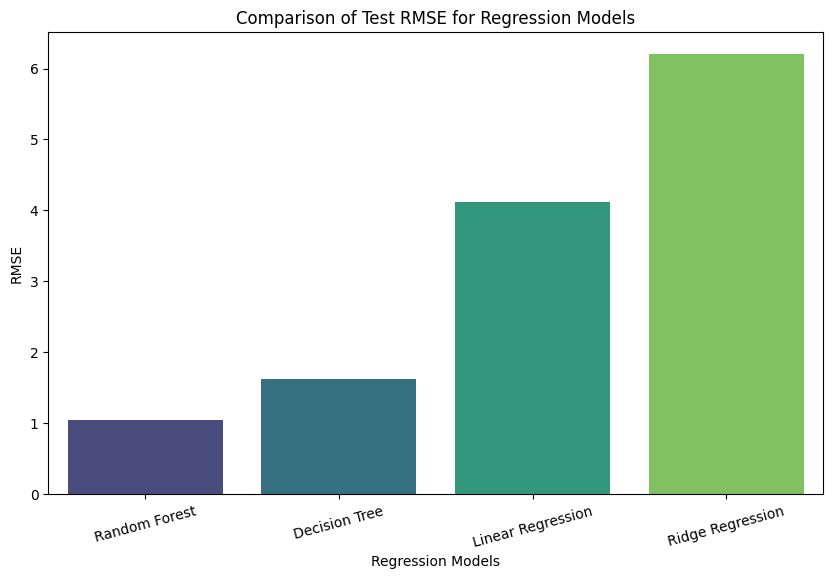

In [19]:
# ===========================================
# RMSE Comparison
# ===========================================

plt.figure(figsize=(10,6))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE",
    palette="viridis"
)

plt.title("Comparison of Test RMSE for Regression Models")

plt.xlabel("Regression Models")

plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.show()

In [20]:
# ===========================================
# Best Model
# ===========================================

best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest


In [25]:
# ===========================================
# Load Best Model (ensure it's fitted)
# ===========================================

best_model = models[best_model_name]

from sklearn.utils.validation import check_is_fitted

try:
    check_is_fitted(best_model)
except Exception:
    # Model isn't fitted (likely due to out-of-order execution); fit now
    best_model.fit(X_train, y_train)

best_model

RandomForestRegressor(n_estimators=50, n_jobs=1, random_state=42)

In [26]:
# ===========================================
# Predictions
# ===========================================

best_predictions = best_model.predict(X_test)

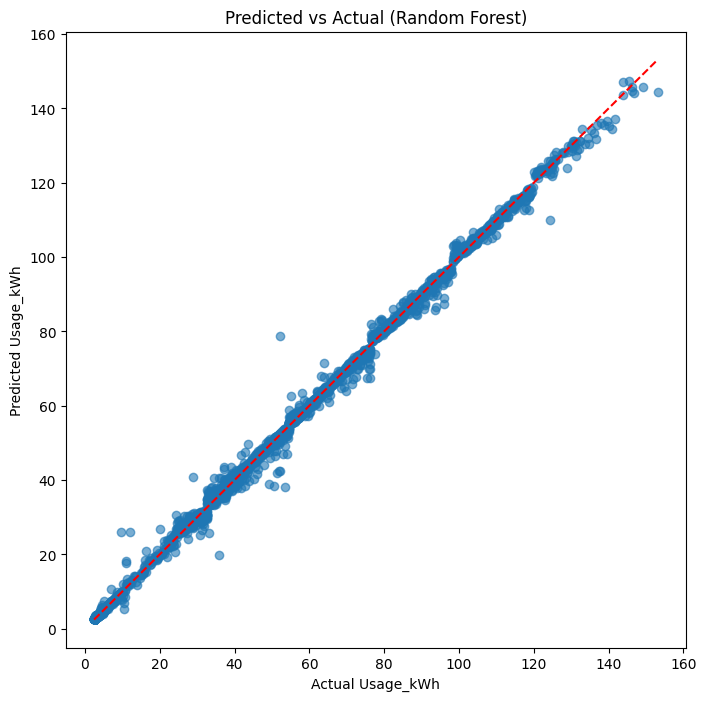

In [27]:
# ===========================================
# Predicted vs Actual
# ===========================================

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Usage_kWh")

plt.ylabel("Predicted Usage_kWh")

plt.title(f"Predicted vs Actual ({best_model_name})")

plt.show()

In [28]:
# ===========================================
# Final Results
# ===========================================

print(final_results)

               Model       MAE      RMSE  R2 Score  CV Mean RMSE
0      Random Forest  0.346099  1.039767  0.999049      2.452315
1      Decision Tree  0.546941  1.618502  0.997696      2.748418
2  Linear Regression  2.668221  4.124352  0.985036      4.739527
3   Ridge Regression  4.325466  6.201066  0.966172      7.600603
